In [1]:

from tensorflow.keras.utils import Sequence
from  math import ceil

class DataGenerator(Sequence):
    # Generates data for Keras
    def __init__(self, image_paths, mask_paths, batch_size=8):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size

    # Denotes the number of batches per epoch
    def __len__(self):
        return ceil(len(self.image_paths) / self.batch_size)

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.mask_paths[idx * self.batch_size:(idx + 1) * self.batch_size]

        images = []
        masks = []
        for img_path, mask_path in zip(batch_x, batch_y):
            img, mask = load_image_mask(img_path, mask_path)
            images.append(img)
            masks.append(mask)

        return np.array(images), np.array(masks)


In [2]:
import os
import glob

# Set the paths to your image and mask directories
img_dir = "E:/PhD/V_M_Dataset/segmented_file - Copy/images/"
mask_dir = "E:/PhD/V_M_Dataset/segmented_file - Copy/masks_error/"

# Get all image and mask files
img_files = sorted(glob.glob(f"{img_dir}/*.jpg"))
mask_files = sorted(glob.glob(f"{mask_dir}/*.jpg"))


In [3]:
print("Shembuj emrash:")
print("Image:", [os.path.basename(p) for p in img_files[:5]])
print("Mask:", [os.path.basename(p) for p in mask_files[:5]])


Shembuj emrash:
Image: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '101.jpg']
Mask: ['0_maska.jpg', '100_maska.jpg', '101_maska.jpg', '102_maska.jpg', '103_maska.jpg']


In [4]:

# Set the paths to your image and mask directories
img_dir = "E:/PhD/V_M_Dataset/segmented_file - Copy/images/"
mask_dir = "E:/PhD/V_M_Dataset/segmented_file - Copy/masks_error/"

# Get all image and mask files
images = sorted([os.path.basename(f) for f in glob.glob(f"{img_dir}/*.jpg")])
masks  = sorted([os.path.basename(f) for f in glob.glob(f"{mask_dir}/*.jpg")])

# Krijojmë set për krahasim
image_ids = set([os.path.splitext(f)[0] for f in images])                 # ['0','1','10','100','101']
mask_ids  = set([f.replace("_maska", "").split(".")[0] for f in masks])   # ['0','100','101','102','103']

# Mbajmë vetëm ato që kanë çift
common_ids = sorted(list(image_ids.intersection(mask_ids)))

print("Çiftet e gjetura:", common_ids)

# Tani për çdo ID krijojmë path real të imazhit dhe maskës
for cid in common_ids:
    img_path  = os.path.join(img_dir, f"{cid}.jpg")
    mask_path = os.path.join(mask_dir, f"{cid}_maska.jpg")
    print("Crop për:", img_path, mask_path)
    # këtu thërret funksionin tënd crop_to_roi(img_path, mask_path)


Çiftet e gjetura: ['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '21', '210', '211', '212', '213', '214', '215', '216', '217', '218', '219', '22', '220', '221', '222', '223', '224', '225', '226',

In [5]:
import cv2
def load_image_mask(img_path, mask_path, target_size=(256,256)):
    # Lexo imazhin (grayscale)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)  # (H,W,1)

    # Lexo maskën (grayscale)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)  # binarizo maskën
    mask = np.expand_dims(mask, axis=-1)   # (H,W,1)

    return img, mask


In [6]:
# Krijo dict për maskat duke hequr "_maska"
mask_dict = {
    os.path.basename(p).replace("_maska","").split(".")[0]: p
    for p in mask_files
}

img_paths = []
mask_paths = []

# Përputh imazhet me maskat sipas ID-së
for img_path in img_files:
    base = os.path.splitext(os.path.basename(img_path))[0]  # p.sh. '100'
    if base in mask_dict:
        img_paths.append(img_path)
        mask_paths.append(mask_dict[base])
    else:
        print(" Nuk gjeta maskë për:", base)

print(f" Matched {len(img_paths)} image-mask pairs.")


 Matched 737 image-mask pairs.


Epoch 1/100
50/50 [==============================] - ETA: 0s - loss: 0.0377 - accuracy: 0.9867 - dice_coef: 0.0207 - iou_coef: 0.0199
Epoch 1: val_loss improved from inf to 0.02126, saving model to error_in_mammo_segmentation.h5
50/50 [==============================] - 12s 205ms/step - loss: 0.0377 - accuracy: 0.9867 - dice_coef: 0.0207 - iou_coef: 0.0199 - val_loss: 0.0213 - val_accuracy: 0.9947 - val_dice_coef: 3.5271e-04 - val_iou_coef: 3.1247e-04
Epoch 2/100
50/50 [==============================] - ETA: 0s - loss: 0.0244 - accuracy: 0.9940 - dice_coef: 0.0148 - iou_coef: 0.0138
Epoch 2: val_loss improved from 0.02126 to 0.02124, saving model to error_in_mammo_segmentation.h5
50/50 [==============================] - 6s 118ms/step - loss: 0.0244 - accuracy: 0.9940 - dice_coef: 0.0148 - iou_coef: 0.0138 - val_loss: 0.0212 - val_accuracy: 0.9947 - val_dice_coef: 2.7958e-04 - val_iou_coef: 2.7594e-04
Epoch 3/100
50/50 [==============================] - ETA: 0s - loss: 0.0064 - accuracy:

Epoch 20/100
50/50 [==============================] - ETA: 0s - loss: 4.7187e-04 - accuracy: 0.9991 - dice_coef: 0.4079 - iou_coef: 0.2623
Epoch 20: val_loss improved from 0.00028 to 0.00024, saving model to error_in_mammo_segmentation.h5
50/50 [==============================] - 6s 120ms/step - loss: 4.7187e-04 - accuracy: 0.9991 - dice_coef: 0.4079 - iou_coef: 0.2623 - val_loss: 2.4456e-04 - val_accuracy: 0.9994 - val_dice_coef: 0.4937 - val_iou_coef: 0.3298
Epoch 21/100
50/50 [==============================] - ETA: 0s - loss: 4.4080e-04 - accuracy: 0.9992 - dice_coef: 0.4231 - iou_coef: 0.2740
Epoch 21: val_loss did not improve from 0.00024
50/50 [==============================] - 6s 119ms/step - loss: 4.4080e-04 - accuracy: 0.9992 - dice_coef: 0.4231 - iou_coef: 0.2740 - val_loss: 2.6892e-04 - val_accuracy: 0.9994 - val_dice_coef: 0.4776 - val_iou_coef: 0.3157
Epoch 22/100
50/50 [==============================] - ETA: 0s - loss: 4.4979e-04 - accuracy: 0.9992 - dice_coef: 0.4376 - io

50/50 [==============================] - 6s 123ms/step - loss: 3.6591e-04 - accuracy: 0.9994 - dice_coef: 0.4616 - iou_coef: 0.3070 - val_loss: 1.9963e-04 - val_accuracy: 0.9995 - val_dice_coef: 0.5011 - val_iou_coef: 0.3364
Epoch 40/100
50/50 [==============================] - ETA: 0s - loss: 3.6247e-04 - accuracy: 0.9994 - dice_coef: 0.4650 - iou_coef: 0.3114
Epoch 40: val_loss did not improve from 0.00020
50/50 [==============================] - 6s 120ms/step - loss: 3.6247e-04 - accuracy: 0.9994 - dice_coef: 0.4650 - iou_coef: 0.3114 - val_loss: 2.0815e-04 - val_accuracy: 0.9995 - val_dice_coef: 0.5241 - val_iou_coef: 0.3572
Epoch 41/100
50/50 [==============================] - ETA: 0s - loss: 3.5203e-04 - accuracy: 0.9994 - dice_coef: 0.4834 - iou_coef: 0.3291
Epoch 41: val_loss improved from 0.00020 to 0.00019, saving model to error_in_mammo_segmentation.h5
50/50 [==============================] - 6s 121ms/step - loss: 3.5203e-04 - accuracy: 0.9994 - dice_coef: 0.4834 - iou_coef:

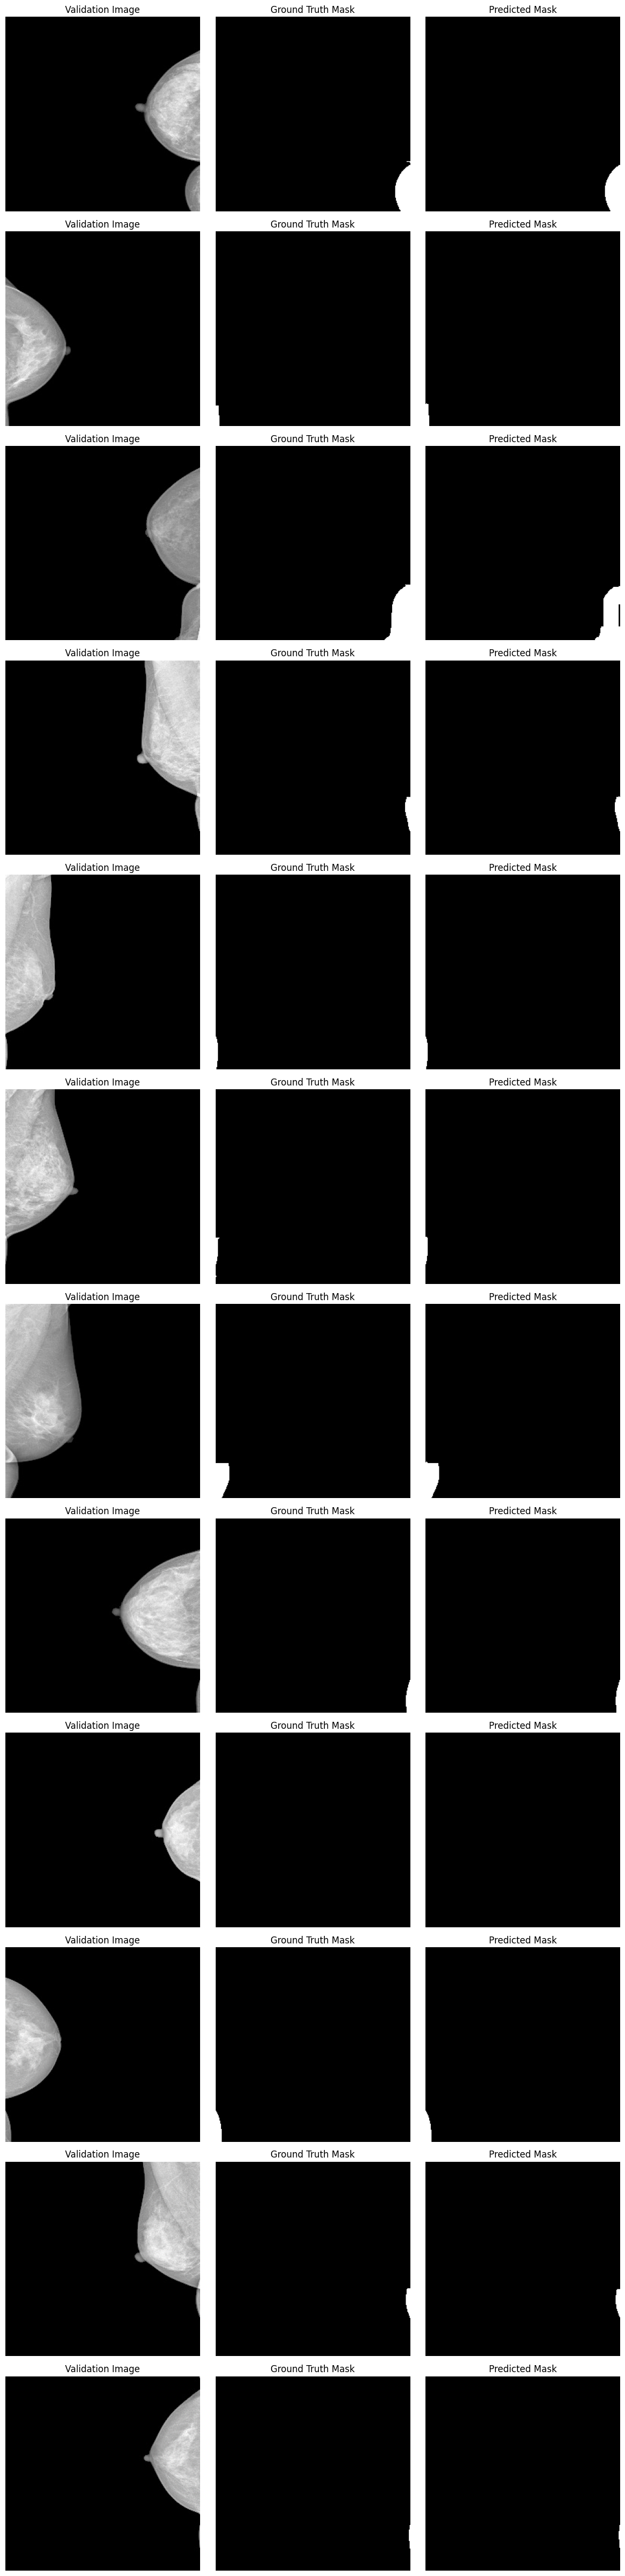

Image shape: (256, 256, 1), dtype: float32
Mask shape: (256, 256, 1), dtype: float32
Best model saved as: error_in_mammo_segmentation.h5


In [8]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
# U-net model
from tensorflow.keras import layers, models

def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    # Decoder
    u2 = layers.UpSampling2D()(b)
    u2 = layers.Concatenate()([u2, c2])
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.Concatenate()([u1, c1])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

# =====================================================
# 1. Ndajmë datasetin
# =====================================================
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths, mask_paths, test_size=0.2, random_state=42)

# Data generators
train_gen = DataGenerator(train_imgs, train_masks)
val_gen = DataGenerator(val_imgs, val_masks)
train_gen.batch_size = 12
val_gen.batch_size = 12

# =====================================================
# 2. Focal Loss
# =====================================================
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        loss = -y_true * alpha * tf.math.pow(1 - y_pred, gamma) * tf.math.log(y_pred) \
               - (1 - y_true) * (1 - alpha) * tf.math.pow(y_pred, gamma) * tf.math.log(1 - y_pred)
        return tf.reduce_mean(loss)
    return focal_loss_fixed

# =====================================================
# 3. Ndërtojmë dhe kompajlojmë modelin
# =====================================================
model = build_unet()
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

model.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', dice_coef, iou_coef])


# =====================================================
# 4. Callbacks (ruajmë modelin më të mirë)
# =====================================================
checkpoint_path = "error_in_mammo_segmentation.h5"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )
]

# =====================================================
# 5. Trajnimi
# =====================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen),
    callbacks=callbacks
)

# =====================================================
# 6. Kontrollojmë disa imazhe nga validimi
# =====================================================
X_val, y_val = val_gen[0]
print("Unique values in a sample of validation masks:", np.unique(y_val))

n_show = min(30, len(X_val))
plt.figure(figsize=(12, 4 * n_show))
for i in range(n_show):
    pred = model.predict(np.expand_dims(X_val[i], axis=0))[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    plt.subplot(n_show, 3, i*3+1)
    plt.imshow(X_val[i].squeeze(), cmap='gray')
    plt.title('Validation Image')
    plt.axis('off')

    plt.subplot(n_show, 3, i*3+2)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')

    plt.subplot(n_show, 3, i*3+3)
    plt.imshow(pred_mask.squeeze(), cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {X_val[0].shape}, dtype: {X_val[0].dtype}")
print(f"Mask shape: {y_val[0].shape}, dtype: {y_val[0].dtype}")
print(f"Best model saved as: {checkpoint_path}")


In [9]:

from sklearn.metrics import f1_score

# Funksionet për Dice dhe IoU me NumPy
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten().astype(np.float32)
    y_pred_f = y_pred.flatten().astype(np.float32)
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten().astype(np.float32)
    y_pred_f = y_pred.flatten().astype(np.float32)
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def evaluate_model(model, val_gen, threshold=0.5):
    dice_scores = []
    iou_scores = []
    f1_scores = []

    for i in range(len(val_gen)):
        x, y_true = val_gen[i]
        y_pred = model.predict(x, verbose=0)
        y_pred = (y_pred > threshold).astype(np.uint8)

        for j in range(len(x)):
            dice = dice_coefficient(y_true[j], y_pred[j])
            iou = iou_score(y_true[j], y_pred[j])
            f1 = f1_score(y_true[j].flatten(), y_pred[j].flatten())

            dice_scores.append(dice)
            iou_scores.append(iou)
            f1_scores.append(f1)

    print("Dice Coefficient: ", np.mean(dice_scores))
    print("IoU Score:       ", np.mean(iou_scores))
    print("F1 Score:        ", np.mean(f1_scores))

    return np.mean(dice_scores), np.mean(iou_scores), np.mean(f1_scores)





In [10]:
model = tf.keras.models.load_model("error_in_mammo_segmentation.h5",
                                    custom_objects={"focal_loss_fixed": focal_loss(), 
                                                    "dice_coef": dice_coef, 
                                                    "iou_coef": iou_coef})
evaluate_model(model, val_gen)

C:\Users\Perdorues\.conda\envs\pytorchenv\lib\site-packages\sklearn\metrics\_classification.py:1757: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
C:\Users\Perdorues\.conda\envs\pytorchenv\lib\site-packages\sklearn\metrics\_classification.py:1757: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_sum))
C:\Users\Perdorues\.conda\envs\pytorchenv\lib\site-packages\sklearn\metrics\_classification.py:1757: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, "true nor predicted", "F-score is", len(true_s

Dice Coefficient:  0.9228480659931965
IoU Score:        0.8942770533982738
F1 Score:         0.8147399521689851


(0.9228480659931965, 0.8942770533982738, 0.8147399521689851)